# 2단계 표준화 잔차 — 실제로 어떻게 일어났는지

`Decay_Slope_PT`(펌프를 끈 뒤 압력이 빠지는 기울기) 하나를 끝까지 따라가면서,
정규화가 **무엇을 계산하고, 왜 필요했고, 원본 값을 훼손하지 않았는지**를 그림으로 확인한다.

셀을 위에서부터 실행하면 캐시된 실데이터로 전부 다시 그려진다.

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

with open("cache/compare4_P1.pkl", "rb") as f:
    RAW = pickle.load(f)

from Cycle_Feature_Extractor import extract_cycle_features

cyc_all, _ = extract_cycle_features(RAW["train"], "P1")
cyc_all = cyc_all[(cyc_all["Prev_SV"] != 0) & (~cyc_all["Excluded"])]
cyc_all = cyc_all.dropna(subset=["Decay_Slope_PT", "PT_at_End"])
print(f"사이클 {len(cyc_all):,}개 (학습 구간, 9/10~9/18)")

사이클 20,524개 (학습 구간, 9/10~9/18)


---
## 1. 예상값은 어디서 오는가 — 회귀선을 실제로 그어본다

학습 구간의 `(PT_at_End, Decay_Slope_PT)` 산점도 위에, 그 점들로 직접 적합한 직선을
겹쳐 그린다. **이 직선의 식이 "예상값"이다** — DB나 외부 값이 아니라 지금 이 산점도
자체에서 나온 것이다.

상관계수 (시작압력 vs 실제기울기) : -0.537
적합된 직선 : 예상기울기 = -0.3288 x 시작압력 + (24.032)

해석: 계수 a 가 음수 -> 시작압력이 커질수록 예상기울기가 더 작아진다(더 음수)
      = 압력이 높을수록 더 가파르게(더 많이) 빠지는 게 '정상' 이라는 뜻


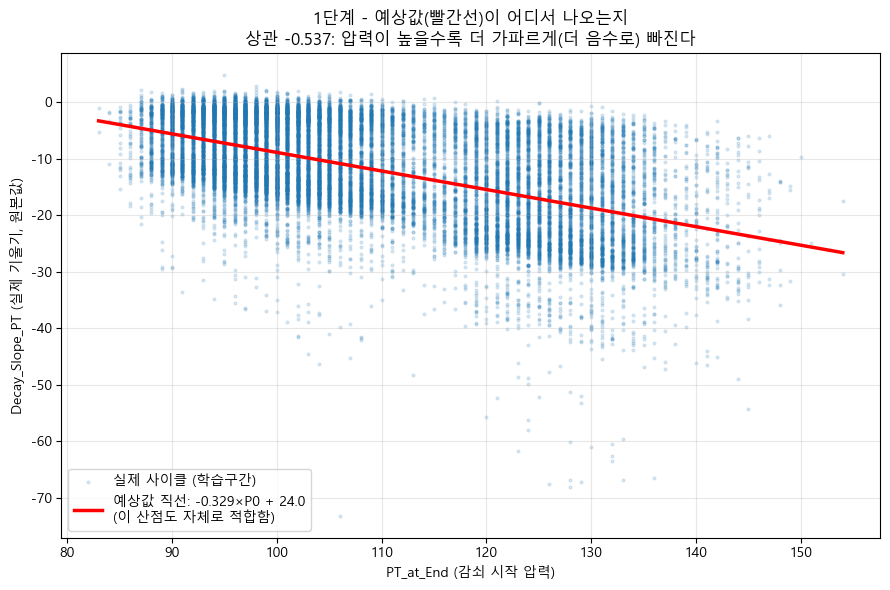

In [2]:
y = cyc_all["Decay_Slope_PT"].to_numpy()
x = cyc_all["PT_at_End"].to_numpy()
a, b = np.polyfit(x, y, 1)
pred = a * x + b
resid = y - pred

corr = np.corrcoef(x, y)[0, 1]
print(f"상관계수 (시작압력 vs 실제기울기) : {corr:+.3f}")
print(f"적합된 직선 : 예상기울기 = {a:.4f} x 시작압력 + ({b:.3f})")
print()
print("해석: 계수 a 가 음수 -> 시작압력이 커질수록 예상기울기가 더 작아진다(더 음수)")
print("      = 압력이 높을수록 더 가파르게(더 많이) 빠지는 게 '정상' 이라는 뜻")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, s=4, alpha=.15, color="tab:blue", label="실제 사이클 (학습구간)")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a * xs + b, color="red", lw=2.5,
        label=f"예상값 직선: {a:.3f}×P0 + {b:.1f}\n(이 산점도 자체로 적합함)")
ax.set_xlabel("PT_at_End (감쇠 시작 압력)")
ax.set_ylabel("Decay_Slope_PT (실제 기울기, 원본값)")
ax.set_title(f"1단계 - 예상값(빨간선)이 어디서 나오는지\n상관 {corr:+.3f}: 압력이 높을수록 더 가파르게(더 음수로) 빠진다")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 2. 예상값을 빼면(잔차) 무슨 일이 생기나

`잔차 = 실제값 - 예상값`. 압력에 따라 기울어져 있던 관계가 **평평해지는지** 확인한다.

잔차와 시작압력의 상관 : -0.0000  (원래 -0.537 였음)


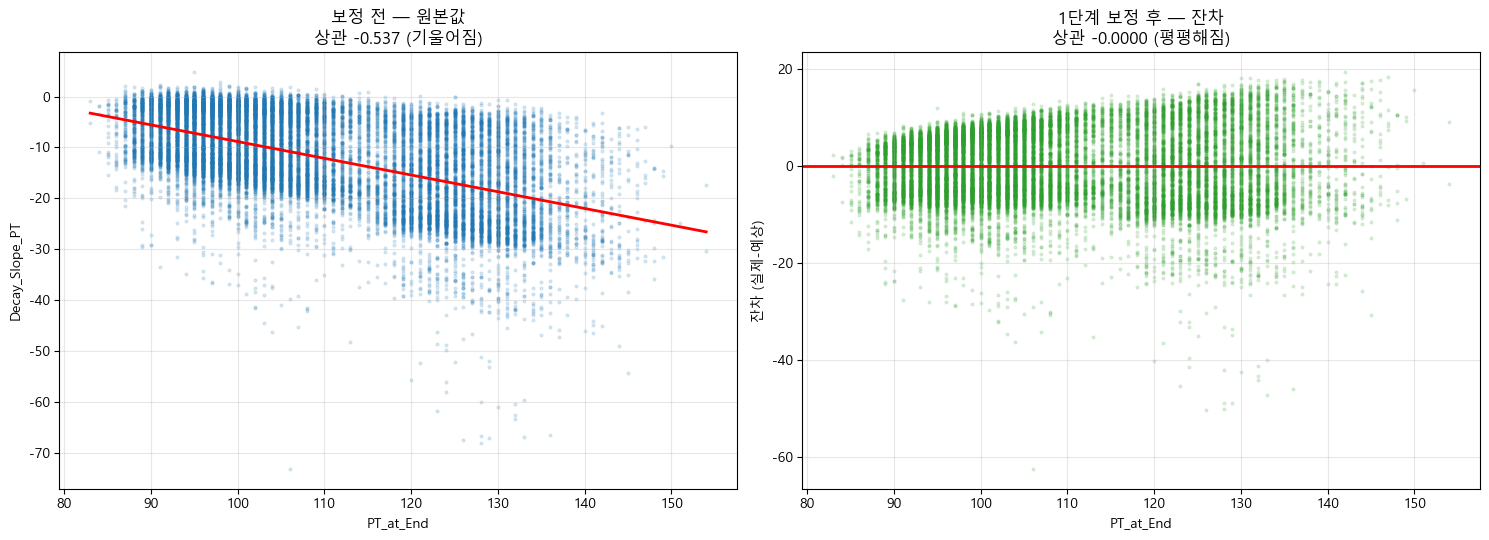

In [3]:
corr_resid = np.corrcoef(x, resid)[0, 1]
print(f"잔차와 시작압력의 상관 : {corr_resid:+.4f}  (원래 {corr:+.3f} 였음)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(x, y, s=4, alpha=.15, color="tab:blue")
axes[0].plot(xs, a * xs + b, color="red", lw=2)
axes[0].set_title(f"보정 전 — 원본값\n상관 {corr:+.3f} (기울어짐)")
axes[0].set_xlabel("PT_at_End"); axes[0].set_ylabel("Decay_Slope_PT"); axes[0].grid(alpha=.3)

axes[1].scatter(x, resid, s=4, alpha=.15, color="tab:green")
axes[1].axhline(0, color="red", lw=2)
axes[1].set_title(f"1단계 보정 후 — 잔차\n상관 {corr_resid:+.4f} (평평해짐)")
axes[1].set_xlabel("PT_at_End"); axes[1].set_ylabel("잔차 (실제-예상)"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 3. 그런데 평평해진 것만으로는 부족하다 — 흩어짐(폭)이 다르다

오른쪽 그림을 자세히 보면 평균은 0 근처로 평평한데, **점들이 퍼진 폭이 왼쪽(낮은 압력)보다
오른쪽(높은 압력)에서 훨씬 넓다.** 이게 "예상흩어짐"이 필요한 이유다.

                  평균  표준편차    건수
시작압력 구간                         
(82.999, 93.0] -0.61  5.12  2477
(93.0, 96.0]   -0.21  5.72  2179
(96.0, 99.0]    0.22  5.91  2172
(99.0, 101.0]   0.28  6.26  1416
(101.0, 105.0]  0.41  6.71  2503
(105.0, 109.0]  0.89  7.04  1639
(109.0, 119.0]  0.22  7.81  2190
(119.0, 124.0] -0.87  8.58  1959
(124.0, 130.0] -0.25  9.35  2203
(130.0, 154.0]  0.21  9.67  1786

구간별 표준편차: 최소 5.12 ~ 최대 9.67  (1.89배 차이)

흩어짐 예측선: |잔차| = 0.0855 x 시작압력 + -3.270
  (E[|잔차|] 를 표준편차로 환산할 때 x sqrt(pi/2) = x1.253)


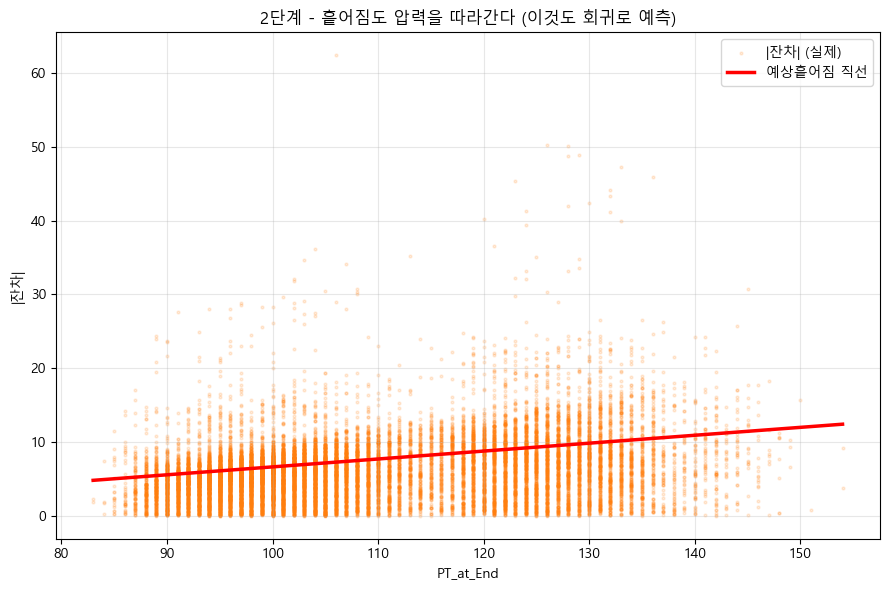

In [4]:
bins = pd.qcut(x, 10, duplicates="drop")
g = pd.DataFrame({"x": x, "resid": resid}).groupby(bins)
spread_table = g["resid"].agg(평균="mean", 표준편차="std", 건수="size")
spread_table.index.name = "시작압력 구간"
print(spread_table.round(2).to_string())
print()
print(f"구간별 표준편차: 최소 {spread_table['표준편차'].min():.2f} ~ "
      f"최대 {spread_table['표준편차'].max():.2f}  "
      f"({spread_table['표준편차'].max()/spread_table['표준편차'].min():.2f}배 차이)")

sa, sb = np.polyfit(x, np.abs(resid), 1)
pred_spread = np.clip(sa * x + sb, 1e-6, None) * np.sqrt(np.pi / 2)
print(f"\n흩어짐 예측선: |잔차| = {sa:.4f} x 시작압력 + {sb:.3f}")
print(f"  (E[|잔차|] 를 표준편차로 환산할 때 x sqrt(pi/2) = x{np.sqrt(np.pi/2):.3f})")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, np.abs(resid), s=4, alpha=.15, color="tab:orange", label="|잔차| (실제)")
order = np.argsort(x)
ax.plot(x[order], pred_spread[order], color="red", lw=2.5, label="예상흩어짐 직선")
ax.set_xlabel("PT_at_End"); ax.set_ylabel("|잔차|")
ax.set_title("2단계 - 흩어짐도 압력을 따라간다 (이것도 회귀로 예측)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 4. 최종 피처 = 잔차 ÷ 예상흩어짐 — 폭까지 균일해지는지 확인

이제 잔차를 그 지점의 예상흩어짐으로 나눈다. **평균도 평평하고 폭도 균일해야** 성공이다.

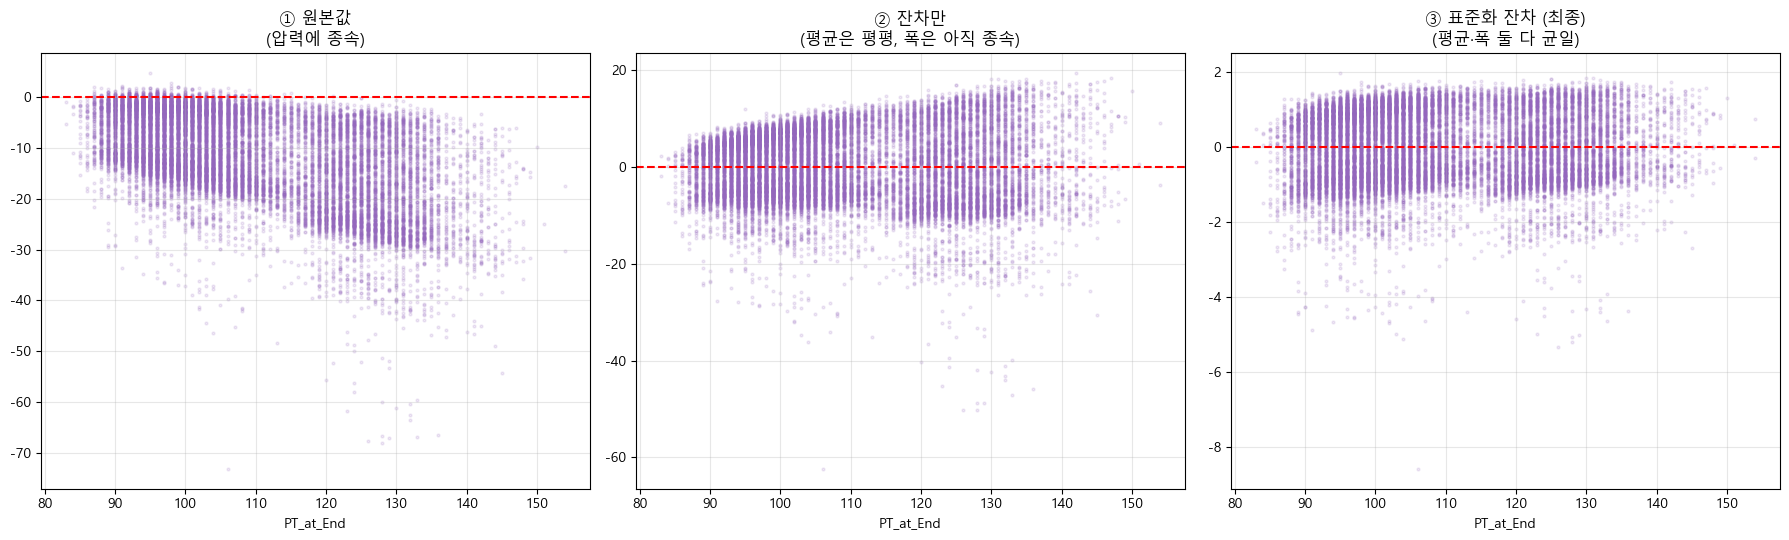

                         평균범위              표준편차범위      표준편차비율
원본           -20.15 ~   -6.40      5.08 ~    9.70       1.91배
잔차            -0.87 ~    0.89      5.12 ~    9.67       1.89배
표준화잔차         -0.11 ~    0.12      0.91 ~    0.98       1.07배


In [5]:
z = resid / pred_spread

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (title, vals) in zip(axes, [
        ("① 원본값\n(압력에 종속)", y),
        ("② 잔차만\n(평균은 평평, 폭은 아직 종속)", resid),
        ("③ 표준화 잔차 (최종)\n(평균·폭 둘 다 균일)", z)]):
    ax.scatter(x, vals, s=4, alpha=.15, color="tab:purple")
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set_title(title); ax.set_xlabel("PT_at_End"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

def stats_by_bin(vals):
    g = pd.Series(vals).groupby(bins)
    return g.mean(), g.std()
print(f"{'':10s} {'평균범위':>18s}  {'표준편차범위':>18s}  {'표준편차비율':>10s}")
for name, vals in [("원본", y), ("잔차", resid), ("표준화잔차", z)]:
    m, s = stats_by_bin(vals)
    print(f"{name:10s} {m.min():8.2f} ~ {m.max():7.2f}  {s.min():8.2f} ~ {s.max():7.2f}  {s.max()/s.min():9.2f}배")

---
## 5. 같은 잔차라도 압력대에 따라 심각도가 다르다 (실제 두 사이클)

②(잔차만)와 ③(표준화 잔차)의 차이가 실제로 판정에 영향을 주는지, 잔차 크기가
비슷한 두 사이클을 직접 골라 비교한다.

In [6]:
cand = pd.DataFrame({"x": x, "resid": resid, "z": z})
lowP = cand[(cand.x < 95) & cand.resid.between(-13, -11)]
hiP = cand[(cand.x > 125) & cand.resid.between(-13, -11)]
if len(lowP) and len(hiP):
    r1, r2 = lowP.iloc[0], hiP.iloc[0]
    print(f"{'':14s} {'시작압력':>8s} {'실제기울기':>10s} {'잔차':>8s} {'표준화잔차':>10s}")
    for label, r in [("낮은 압력대", r1), ("높은 압력대", r2)]:
        actual = a * r.x + b + r.resid
        print(f"{label:14s} {r.x:8.1f} {actual:10.2f} {r.resid:8.2f} {r.z:10.2f}시그마")
    print()
    print("잔차는 둘 다 -12 근처로 같지만, 표준화 잔차는 다르다.")
    print(f"  -> 낮은 압력대에서 -12는 {abs(r1.z):.1f}시그마 벗어난 것 (드묾, 진짜 이상 후보)")
    print(f"  -> 높은 압력대에서 -12는 {abs(r2.z):.1f}시그마 벗어난 것 (흔함, 정상 범위)")

                   시작압력      실제기울기       잔차      표준화잔차
낮은 압력대             92.0     -17.94   -11.71      -2.03시그마
높은 압력대            131.0     -31.37   -12.33      -1.24시그마

잔차는 둘 다 -12 근처로 같지만, 표준화 잔차는 다르다.
  -> 낮은 압력대에서 -12는 2.0시그마 벗어난 것 (드묾, 진짜 이상 후보)
  -> 높은 압력대에서 -12는 1.2시그마 벗어난 것 (흔함, 정상 범위)


---
## 6. 원본값이 훼손됐는가 — 두 가지로 확인

**(a) 원본 컬럼 자체는 건드리지 않는다.** `Cycle_Normalizer.transform()`은 `_z` 라는
**새 컬럼을 추가**할 뿐, `Decay_Slope_PT` 원본은 그대로 남아있다.

**(b) 정보 손실이 없다 — 되돌릴 수 있다.** 이 변환은 같은 사이클의 `PT_at_End`만 알면
`z` 로부터 원본값을 정확히 복원할 수 있는 **가역 변환**이다.

```
원본값 = z × 예상흩어짐 + 예상값
```

버려지는 정보가 없다는 뜻이다 — 그냥 "압력 조건을 고려했을 때 상대적으로 얼마나
벗어났는가"로 표현만 바꾼 것이다.

원본 컬럼이 그대로 남아있는지 확인: cyc_all['Decay_Slope_PT'] 은 여전히 원본 스케일
                  count   mean   std    min    25%    50%   75%   max
Decay_Slope_PT  20524.0 -11.75  8.69 -73.22 -16.93 -10.85 -4.38  4.84

z 로부터 원본을 되돌린 값과 실제 원본의 최대 오차: 0.0000000000
  -> 0에 가까움 = 정보 손실 없는 가역 변환이 맞다는 뜻


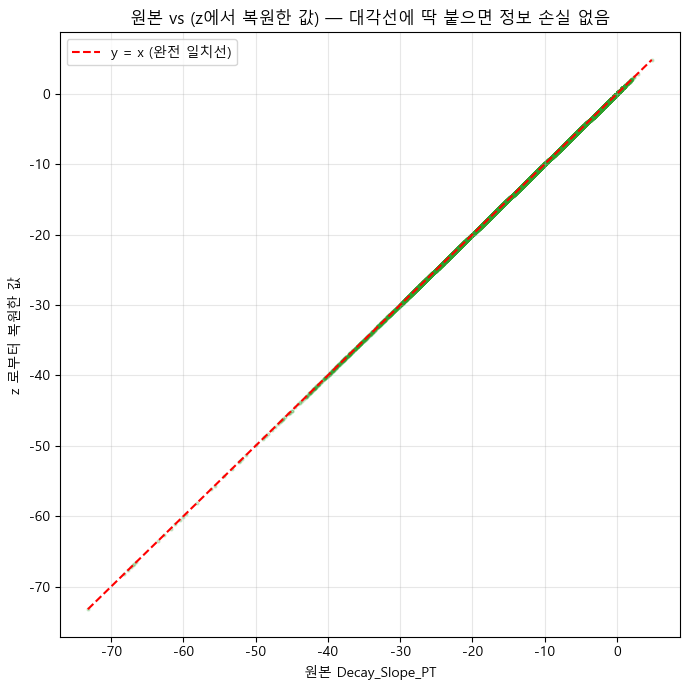

In [7]:
reconstructed = z * pred_spread + pred
max_err = np.abs(reconstructed - y).max()
print(f"원본 컬럼이 그대로 남아있는지 확인: cyc_all['Decay_Slope_PT'] 은 여전히 원본 스케일")
print(cyc_all[["Decay_Slope_PT"]].describe().T.round(2).to_string())
print()
print(f"z 로부터 원본을 되돌린 값과 실제 원본의 최대 오차: {max_err:.10f}")
print("  -> 0에 가까움 = 정보 손실 없는 가역 변환이 맞다는 뜻")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, reconstructed, s=4, alpha=.2, color="tab:green")
lims = [y.min(), y.max()]
ax.plot(lims, lims, color="red", lw=1.5, ls="--", label="y = x (완전 일치선)")
ax.set_xlabel("원본 Decay_Slope_PT"); ax.set_ylabel("z 로부터 복원한 값")
ax.set_title("원본 vs (z에서 복원한 값) — 대각선에 딱 붙으면 정보 손실 없음")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 7. 실제 모델이 쓴 정규화기와 비교 (검증)

지금까지는 이 노트북에서 즉석으로 회귀를 다시 돌린 것이다. `Cycle_AE_v3.ipynb` 가
실제로 저장해 둔 정규화기(`models_v3/normalizer_P1.pkl`)와 계수가 일치하는지 확인한다.

In [8]:
import joblib
norm = joblib.load("models_v3/normalizer_P1.pkl")
beta, gamma, floor = norm.coef_["Decay_Slope_PT"]
print(f"이 노트북에서 방금 적합: a={a:.4f}, b={b:.3f}")
print(f"실제 모델이 저장해 둔 값: a={beta[0]:.4f}, b={beta[1]:.3f}")
print("(같은 학습구간, 같은 기준변수라 일치해야 한다)")

report = norm.report(norm.transform(cyc_all))
print()
print(report.to_string(index=False))

이 노트북에서 방금 적합: a=-0.3288, b=24.032
실제 모델이 저장해 둔 값: a=-0.3288, b=24.032
(같은 학습구간, 같은 기준변수라 일치해야 한다)

              피처          기준변수  원본 상관  정규화 후 상관  정규화 후 평균  정규화 후 표준편차
  Decay_Slope_PT     PT_at_End -0.537     0.007    -0.001       0.947
  Decay_Slope_FT     FT_at_End -0.883    -0.001     0.000       1.098
FT_Jump_From_Pre PreBuildUp_FT -0.520    -0.000     0.000       1.533
    Cum_FT_Error       SV_mean  0.899     0.005    -0.001       0.986
          FT_std       FT_mean  0.872     0.018    -0.006       1.032
 Current_Proxy_I       PT_mean  0.997    -0.001     0.000       1.011
